# Getting excess returns right

A factor regression starts with an economic measurement contract: complete months, simple ETF returns, consistent percentage units, and one subtraction of the risk-free rate. This constructed example makes the original unit and partial-month errors visible before any model is fitted.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Goal

Follow a price move from 100 to 102 through month selection, return
calculation, percentage conversion, and excess-return construction.
Every price and factor value below is **constructed**, not market data.
The three declared month-end sessions are a small fixture; they do not
substitute for the production workflow's complete daily-session checks.

A date label is not evidence that a month is complete. Likewise,
an observation month does not establish when a factor was published.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib.ticker import PercentFormatter

FIGURES = ROOT / "research" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})
prices = pd.Series(
    [100.0, 100.5, 102.0, 101.0, 103.02, 102.8, 104.0],
    index=pd.to_datetime([
        "2024-12-31", "2025-01-02", "2025-01-31", "2025-02-03",
        "2025-02-28", "2025-03-03", "2025-03-14",
    ]), name="Constructed adjusted close",
)
expected_end = pd.Series(
    pd.to_datetime(["2024-12-31", "2025-01-31", "2025-02-28", "2025-03-31"]),
    index=pd.period_range("2024-12", "2025-03", freq="M"),
)
display(prices.to_frame())

,Constructed adjusted close
2024-12-31,100.00
2025-01-02,100.50
2025-01-31,102.00
2025-02-03,101.00
2025-02-28,103.02
2025-03-03,102.80
2025-03-14,104.00


### 1. Keep only completed months

December supplies January's starting price. The latest March quote
is dated March 14, before the declared March 31 session; it cannot be
treated as a full March observation. No absent price is forward filled.

In [3]:
month_key = prices.index.to_period("M")
observed_end = pd.Series(prices.index, index=month_key).groupby(level=0).last()
month_prices = prices.groupby(month_key).last()
complete = observed_end.eq(expected_end)
coverage = pd.DataFrame({
    "Last observed date": observed_end,
    "Required month end": expected_end,
    "Complete month": complete,
    "Last constructed price": month_prices,
})
complete_prices = month_prices.loc[complete]
simple_returns = complete_prices.pct_change(fill_method=None).dropna()
assert simple_returns.index.tolist() == list(pd.period_range("2025-01", "2025-02", freq="M"))
np.testing.assert_allclose(simple_returns.to_numpy(), [0.02, 0.01], atol=1e-14)
display(coverage)

,Last observed date,Required month end,Complete month,Last constructed price
2024-12,2024-12-31,2024-12-31,True,100.00
2025-01,2025-01-31,2025-01-31,True,102.00
2025-02,2025-02-28,2025-02-28,True,103.02
2025-03,2025-03-14,2025-03-31,False,104.00


### 2. Convert the supplied percentages once

For an ETF, $y_t=P_t/P_{t-1}-1-RF_t$. The French `Mkt-RF`
column is **already** an excess return; SMB, HML, RMW, CMA, and
momentum are long–short factor returns. Do not subtract RF again
from these regressors. The factor table here is an illustrative fixture.

In [4]:
source_percent = pd.DataFrame(
    {"Mkt-RF": [1.7, 0.8], "RF": [0.3, 0.2]},
    index=pd.period_range("2025-01", "2025-02", freq="M"),
)
factors = source_percent / 100.0
assert simple_returns.index.equals(factors.index)
excess = simple_returns - factors["RF"]
log_returns = np.log(complete_prices / complete_prices.shift(1)).dropna()
legacy_expression = log_returns - source_percent["RF"]
comparison = pd.DataFrame({
    "ETF simple return (%)": simple_returns * 100,
    "RF (%)": source_percent["RF"],
    "Correct excess return (%)": excess * 100,
    "Legacy expression (inconsistent units)": legacy_expression,
})
np.testing.assert_allclose(excess.to_numpy(), [0.017, 0.008], atol=1e-14)
display(comparison.round(6))

,ETF simple return (%),RF (%),Correct excess return (%),Legacy expression (inconsistent units)
2025-01,2.0,0.3,1.7,-0.280197
2025-02,1.0,0.2,0.8,-0.190050


### 3. Separate a unit error from a return-definition choice

The January excess return is 1.7%, obtained from 2.0% minus 0.3%.
Log returns are also legitimate quantities, but they do not equal
simple returns and cannot silently replace them in this model.
The second panel shows their difference for constructed price shocks.

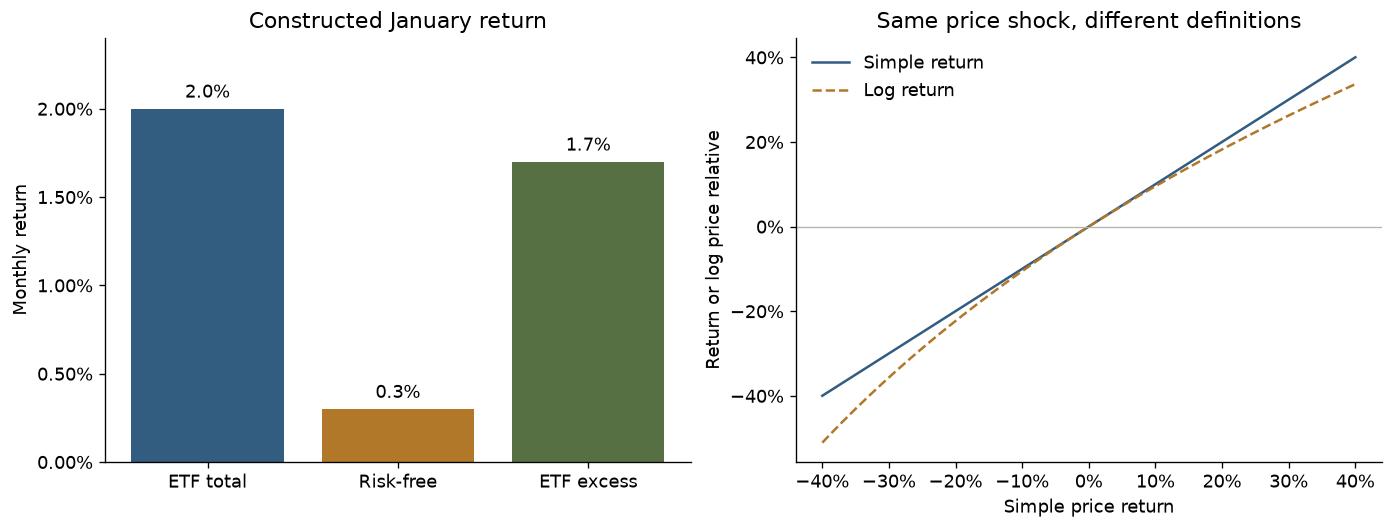

In [5]:
shocks = np.linspace(-0.4, 0.4, 161)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), layout="constrained")
values = [simple_returns.iloc[0], factors["RF"].iloc[0], excess.iloc[0]]
bars = axes[0].bar(["ETF total", "Risk-free", "ETF excess"], values,
                   color=["#335C81", "#B07828", "#567044"])
axes[0].bar_label(bars, labels=[f"{x:.1%}" for x in values], padding=4)
axes[0].set(ylim=(0, 0.024), title="Constructed January return", ylabel="Monthly return")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].plot(shocks, shocks, color="#335C81", label="Simple return")
axes[1].plot(shocks, np.log1p(shocks), color="#B07828", linestyle="--", label="Log return")
axes[1].axhline(0, color="0.7", linewidth=0.8)
axes[1].set(title="Same price shock, different definitions", xlabel="Simple price return",
            ylabel="Return or log price relative")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(frameon=False)
fig.savefig(FIGURES / "topic_return_alignment.png", dpi=160, bbox_inches="tight")
plt.show()

### 4. Keep the economic checks beside the arithmetic

These two constructed months make the ETF excess return equal to the
market excess return. Subtracting RF a second time from `Mkt-RF`
breaks that identity. Missing a required month must fail a production
calculation; dropping a broken middle month and taking the next price
ratio would create a multi-month return with a misleading monthly label.

In [6]:
np.testing.assert_allclose(excess, factors["Mkt-RF"], atol=1e-14)
assert not complete.loc[pd.Period("2025-03", freq="M")]
assert np.diff(complete_prices.index.asi8).tolist() == [1, 1]
np.testing.assert_allclose(
    log_returns, np.log1p(simple_returns), atol=1e-14
)
display(pd.DataFrame({
    "Correct Mkt-RF (%)": factors["Mkt-RF"] * 100,
    "Incorrect second RF subtraction (%)": (factors["Mkt-RF"] - factors["RF"]) * 100,
}))
display(Markdown(
    "**Result:** the constructed January excess return is **1.7%**; "
    "the partial March observation is excluded. These checks establish "
    "the arithmetic contract, not the quality or historical availability "
    "of any downloaded data."
))

,Correct Mkt-RF (%),Incorrect second RF subtraction (%)
2025-01,1.7,1.4
2025-02,0.8,0.6


**Result:** the constructed January excess return is **1.7%**; the partial March observation is excluded. These checks establish the arithmetic contract, not the quality or historical availability of any downloaded data.

## Takeaway

A regression cannot repair incompatible units or a partial-month return.
The empirical study applies this contract to pinned data and validates
actual exchange-session coverage. Continue to the
[SVD geometry notebook](../02-svd-geometry/study.ipynb), or inspect the
[data sources](../../research/SOURCES.md) and [protocol](../../research/PROTOCOL.md).